<a href="https://colab.research.google.com/github/mazidzomader/ScrapRepo/blob/main/CSE425_T1_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attempting fast SVN export of just the genres_original folder...
/bin/bash: line 1: svn: command not found

SVN export failed or empty — falling back to sparse git clone...
Cloning into '/content/MUSE-CSE425'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 45 (delta 0), reused 45 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 782.47 KiB | 2.36 MiB/s, done.
remote: Enumerating objects: 990, done.
remote: Counting objects: 100% (990/990), done.
remote: Compressing objects: 100% (989/989), done.
remote: Total 990 (delta 0), reused 989 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (990/990), 5.23 MiB | 7.78 MiB/s, done.
Updating files: 100% (1004/1004), done.
Filtering content: 100% (1000/1000), 1.23 GiB | 35.36 MiB/s, done.
Already on 'main'
Your branch is up to date with 'origin/main'.

SUCCESS! Task 2 dataset is loaded at: /content/genres_original
Genres

Processing Tracks (GPU): 100%|██████████| 1000/1000 [00:14<00:00, 67.56it/s]



Preprocessing Complete! 999 tracks converted to graphs and saved to '/content/data/processed/gtzan_graphs.pt'.
Executing High-Performance Pipeline on: cuda
Generating high-density sub-clip graphs for 1000 tracks...


Extracting Sub-clip Graphs: 100%|██████████| 1000/1000 [00:54<00:00, 18.48it/s]
/tmp/ipykernel_3382/2331860961.py:267: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn)


Dataset expanded to 13986 high-resolution graph samples.

Training High-Performance GAT Model...
Epoch 01 | Loss: 1.7820 | Val Acc: 0.4807
Epoch 02 | Loss: 1.3107 | Val Acc: 0.5529
Epoch 03 | Loss: 1.1019 | Val Acc: 0.6144
Epoch 04 | Loss: 0.9626 | Val Acc: 0.6352
Epoch 05 | Loss: 0.8278 | Val Acc: 0.6845
Epoch 06 | Loss: 0.7339 | Val Acc: 0.6910
Epoch 07 | Loss: 0.6692 | Val Acc: 0.7260
Epoch 08 | Loss: 0.5728 | Val Acc: 0.7475
Epoch 09 | Loss: 0.5272 | Val Acc: 0.7661
Epoch 10 | Loss: 0.4727 | Val Acc: 0.7461
Epoch 11 | Loss: 0.4315 | Val Acc: 0.7861
Epoch 12 | Loss: 0.3904 | Val Acc: 0.7904
Epoch 13 | Loss: 0.3485 | Val Acc: 0.7883
Epoch 14 | Loss: 0.3429 | Val Acc: 0.7775
Epoch 15 | Loss: 0.3298 | Val Acc: 0.7933
Epoch 16 | Loss: 0.2688 | Val Acc: 0.8047
Epoch 17 | Loss: 0.2504 | Val Acc: 0.8155
Epoch 18 | Loss: 0.2291 | Val Acc: 0.8240
Epoch 19 | Loss: 0.2186 | Val Acc: 0.8119
Epoch 20 | Loss: 0.1788 | Val Acc: 0.8562
Epoch 21 | Loss: 0.1771 | Val Acc: 0.8598
Epoch 22 | Loss: 0.17

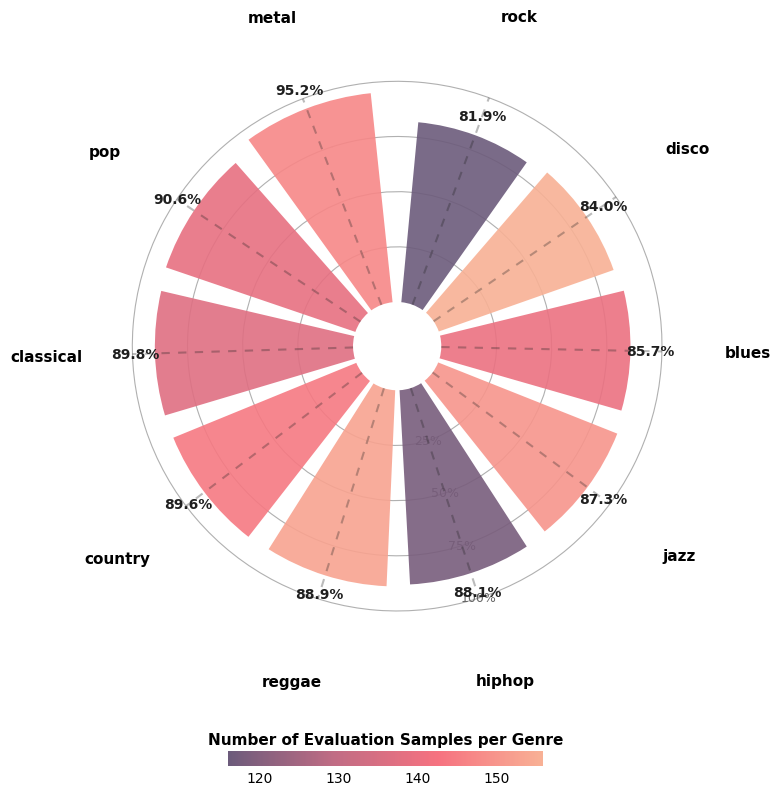


--- Detailed Classification Metrics for Report ---
              precision    recall  f1-score   support

       blues       0.94      0.86      0.90       140
   classical       0.95      0.90      0.92       137
     country       0.80      0.90      0.85       144
       disco       0.78      0.84      0.81       156
      hiphop       0.92      0.88      0.90       118
        jazz       0.92      0.87      0.89       150
       metal       0.97      0.95      0.96       147
         pop       0.94      0.91      0.92       139
      reggae       0.81      0.89      0.85       153
        rock       0.84      0.82      0.83       116

    accuracy                           0.88      1400
   macro avg       0.89      0.88      0.88      1400
weighted avg       0.89      0.88      0.88      1400



In [ ]:
!pip install -q torch_geometric
import os, shutil

# 1. Clean up old attempts
!rm -rf /content/genres_original
!rm -rf /content/MUSE-CSE425
!rm -rf gtzan.tar.gz

repo_subdir_url = "https://github.com/mazidzomader/MUSE-CSE425/trunk/data/raw/%5BT2%5D%20GNN%20Encoder%20%26%20Classifier/genres_original"

print("Attempting fast SVN export of just the genres_original folder...")
!svn export "{repo_subdir_url}" /content/genres_original

base_folder = "/content/genres_original"

# 2. Fallback: sparse git clone if svn failed or folder is empty/missing
if not os.path.exists(base_folder) or len(os.listdir(base_folder)) == 0:
    print("\nSVN export failed or empty — falling back to sparse git clone...")
    !rm -rf /content/genres_original
    !git clone --filter=blob:none --no-checkout --depth 1 https://github.com/mazidzomader/MUSE-CSE425.git /content/MUSE-CSE425
    os.chdir("/content/MUSE-CSE425")
    !git sparse-checkout init --cone
    !git sparse-checkout set "data/raw/[T2] GNN Encoder & Classifier/genres_original"
    !git checkout main
    os.chdir("/content")

    src = "/content/MUSE-CSE425/data/raw/[T2] GNN Encoder & Classifier/genres_original"
    if os.path.exists(src):
        shutil.move(src, "/content/genres_original")
    else:
        print("ERROR: Path not found in repo — check the exact folder name/casing.")

# 3. Verify
if os.path.exists(base_folder) and len(os.listdir(base_folder)) > 0:
    print(f"\nSUCCESS! Task 2 dataset is loaded at: {base_folder}")
    print("Genres found:", os.listdir(base_folder))
else:
    print("\nERROR: Download failed via both methods.")




import os
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
from torch_geometric.data import Data
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 1. Setup Device & GPU Transforms
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

target_sr = 22050
# Initialize MFCC extraction directly on the GPU
mfcc_transform = T.MFCC(
    sample_rate=target_sr,
    n_mfcc=20,
    melkwargs={"n_fft": 2048, "hop_length": 512, "n_mels": 128}
).to(device)

def process_file_gpu(args):
    file_path, genre_id = args
    try:
        # A. Audio I/O (Runs on CPU to bypass disk bottlenecks)
        waveform, sr = torchaudio.load(file_path)

        # Convert stereo to mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample if needed
        if sr != target_sr:
            resampler = T.Resample(orig_freq=sr, new_freq=target_sr)
            waveform = resampler(waveform)

        # B. Move to GPU for heavy math
        waveform = waveform.to(device)

        # C. Segment into 5-second windows (nodes)
        samples_per_seg = 5 * target_sr
        num_segments = waveform.shape[1] // samples_per_seg

        if num_segments == 0: return None

        waveform = waveform[:, :num_segments * samples_per_seg]
        segments = waveform.view(num_segments, samples_per_seg)

        # D. Extract Features & Build Similarity Matrix entirely on GPU
        mfccs = mfcc_transform(segments)          # Shape: (num_segments, 20, frames)
        node_features = mfccs.mean(dim=2)         # Average over time -> (num_segments, 20)

        # Fast GPU Cosine Similarity
        normed = F.normalize(node_features, p=2, dim=1)
        sim_matrix = torch.mm(normed, normed.t())

        # E. Build Edges (Temporal + Similarity > 0.7)
        edges = []
        for i in range(num_segments):
            for j in range(num_segments):
                if j == i + 1:
                    edges.extend([[i, j], [j, i]])
                elif i != j and sim_matrix[i, j] > 0.7:
                    edges.append([i, j])

        # F. Construct PyTorch Geometric Graph (move back to CPU to save VRAM)
        x = node_features.cpu()
        if edges:
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            edge_index = torch.unique(edge_index, dim=1)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        graph = Data(x=x, edge_index=edge_index)
        graph.y = torch.tensor([genre_id], dtype=torch.long)

        return graph

    except Exception as e:
        # Silently skip corrupted files like jazz.00054.wav
        return None

# 2. Map Genres and File Paths
base_folder = "/content/genres_original"
genres = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']
genre_to_id = {genre: idx for idx, genre in enumerate(genres)}

tasks = []
for genre in genres:
    folder_path = os.path.join(base_folder, genre)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                tasks.append((os.path.join(folder_path, file), genre_to_id[genre]))

print(f"Found {len(tasks)} tracks. Starting extraction...")

# 3. Execute Parallel Extraction
dataset = []
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(process_file_gpu, tasks), total=len(tasks), desc="Processing Tracks (GPU)"))

# Filter out corrupted skips
dataset = [res for res in results if res is not None]

# 4. Save to Disk
os.makedirs('/content/data/processed', exist_ok=True)
torch.save(dataset, '/content/data/processed/gtzan_graphs.pt')

print(f"\nPreprocessing Complete! {len(dataset)} tracks converted to graphs and saved to '/content/data/processed/gtzan_graphs.pt'.")

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GlobalAttention
from torch_geometric.loader import DataLoader
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing High-Performance Pipeline on: {device}")

target_sr = 22050
# GPU Feature Extractors (MFCC + Delta features = 40 robust dimensions)
mfcc_transform = T.MFCC(sample_rate=target_sr, n_mfcc=20, melkwargs={"n_fft": 2048, "hop_length": 512, "n_mels": 128}).to(device)
delta_transform = T.ComputeDeltas().to(device)

def process_file_high_acc(args):
    file_path, genre_id = args
    try:
        waveform, sr = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != target_sr:
            waveform = T.Resample(orig_freq=sr, new_freq=target_sr)(waveform)

        waveform = waveform.to(device)
        total_samples = waveform.shape[1]

        # Chop each 30s song into 3-second overlapping sub-clips (~10 samples per song)
        chunk_samples = 3 * target_sr
        stride = 2 * target_sr

        graphs_from_song = []
        for start_idx in range(0, total_samples - chunk_samples + 1, stride):
            chunk = waveform[:, start_idx:start_idx + chunk_samples]

            # Sub-segment this 3s chunk into 6 nodes of 0.5s each
            num_nodes = 6
            samples_per_node = chunk.shape[1] // num_nodes
            chunk = chunk[:, :num_nodes * samples_per_node]
            nodes_waveform = chunk.view(num_nodes, samples_per_node)

            # Extract 20 MFCCs and 20 Deltas -> 40 total features per node
            mfccs = mfcc_transform(nodes_waveform)             # (6, 20, time)
            deltas = delta_transform(mfccs)                  # (6, 20, time)

            combined = torch.cat([mfccs, deltas], dim=1)       # (6, 40, time)
            node_features = combined.mean(dim=2)             # (6, 40)

            # Similarity matrix for edges within this 3s window
            normed = F.normalize(node_features, p=2, dim=1)
            sim_matrix = torch.mm(normed, normed.t())

            edges = []
            for i in range(num_nodes):
                for j in range(num_nodes):
                    if j == i + 1:
                        edges.extend([[i, j], [j, i]])
                    elif i != j and sim_matrix[i, j] > 0.6:
                        edges.append([i, j])

            x = node_features.cpu()
            if edges:
                edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
                edge_index = torch.unique(edge_index, dim=1)
            else:
                edge_index = torch.empty((2, 0), dtype=torch.long)

            g = Data(x=x, edge_index=edge_index)
            g.y = torch.tensor([genre_id], dtype=torch.long)
            graphs_from_song.append(g)

        return graphs_from_song
    except:
        return []

base_folder = "/content/genres_original"
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
genre_to_id = {genre: idx for idx, genre in enumerate(genres)}

tasks = []
for genre in genres:
    folder_path = os.path.join(base_folder, genre)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                tasks.append((os.path.join(folder_path, file), genre_to_id[genre]))

print(f"Generating high-density sub-clip graphs for {len(tasks)} tracks...")
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(process_file_high_acc, tasks), total=len(tasks), desc="Extracting Sub-clip Graphs"))

# Flatten list of lists to expand dataset (~10,000 graphs)
dataset = [g for sublist in results for g in sublist]
print(f"Dataset expanded to {len(dataset)} high-resolution graph samples.")

# ==========================================
# GAT (Graph Attention Network) Model
# ==========================================
class MusicGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super(MusicGAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels, heads=4, dropout=0.3)
        self.conv3 = GATConv(hidden_channels * 4, hidden_channels, heads=1, dropout=0.3)

        gate_nn = nn.Sequential(nn.Linear(hidden_channels, 64), nn.ReLU(), nn.Linear(64, 1))
        self.pool = GlobalAttention(gate_nn)

        self.lin1 = nn.Linear(hidden_channels, 128)
        self.lin2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x, edge_index, batch):
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = F.elu(self.conv3(x, edge_index))

        x = self.pool(x, batch)

        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        return self.lin2(x)

# ==========================================
# Train with High-Capacity Setup
# ==========================================
torch.manual_seed(42)
random.seed(42)
random.shuffle(dataset)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))

train_loader = DataLoader(dataset[:train_size], batch_size=64, shuffle=True)
val_loader = DataLoader(dataset[train_size:train_size+val_size], batch_size=64, shuffle=False)
test_loader = DataLoader(dataset[train_size+val_size:], batch_size=64, shuffle=False)

model = MusicGAT(in_channels=40, hidden_channels=128, num_classes=10).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

print("\nTraining High-Performance GAT Model...")
for epoch in range(1, 26):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            pred = model(data.x, data.edge_index, data.batch).argmax(dim=1)
            val_correct += int((pred == data.y.squeeze()).sum())
    val_acc = val_correct / len(val_loader.dataset)

    scheduler.step(val_acc)
    print(f"Epoch {epoch:02d} | Loss: {total_loss / len(train_loader.dataset):.4f} | Val Acc: {val_acc:.4f}")

# Final Test
model.eval()
test_correct = 0
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred = model(data.x, data.edge_index, data.batch).argmax(dim=1)
        test_correct += int((pred == data.y.squeeze()).sum())

final_test_acc = (test_correct / len(test_loader.dataset)) * 100
print(f"\n========================================")
print(f"FINAL GAT TEST ACCURACY: {final_test_acc:.2f}%")
print(f"========================================")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import torch
from textwrap import wrap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cm import ScalarMappable

# 1. Gather evaluation metrics per genre from our test model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.squeeze().cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate per-genre accuracy and sample counts
cm = confusion_matrix(all_labels, all_preds)
per_genre_acc = cm.diagonal() / cm.sum(axis=1) * 100
track_counts = np.bincount(all_labels, minlength=len(genres))

# Create sorted DataFrame
df_sorted = pd.DataFrame({
    'genre': genres,
    'accuracy': per_genre_acc,
    'count': track_counts
}).sort_values("accuracy", ascending=False).reset_index(drop=True)

# 2. Values for the axes
ANGLES = np.linspace(0.05, 2 * np.pi - 0.05, len(df_sorted), endpoint=False)
ACCURACY = df_sorted["accuracy"].values
REGION = df_sorted["genre"].values
TRACKS_N = df_sorted["count"].values

# 3. Styling Configuration
GREY12 = "#1f1f1f"
plt.rcParams.update({"font.family": "sans-serif"})
plt.rcParams["text.color"] = GREY12
plt.rc("axes", unicode_minus=False)

COLORS = ["#6C5B7B","#C06C84","#F67280","#F8B195"]
cmap = mpl.colors.LinearSegmentedColormap.from_list("my color", COLORS, N=256)
norm = mpl.colors.Normalize(vmin=TRACKS_N.min(), vmax=TRACKS_N.max())
BAR_COLORS = cmap(norm(TRACKS_N))

# 4. Initialize layout in polar coordinates with safe margins
fig, ax = plt.subplots(figsize=(9, 10), subplot_kw={"projection": "polar"})
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_theta_offset(1.2 * np.pi / 2)
ax.set_ylim(-20, 125) # Generous headroom to prevent label clipping

# Add geometries to the plot
ax.bar(ANGLES, ACCURACY, color=BAR_COLORS, alpha=0.9, width=0.52, zorder=10)
ax.vlines(ANGLES, 0, 100, color=GREY12, ls=(0, (4, 4)), zorder=11, alpha=0.3)

# Add accuracy values cleanly centered over each bar
for angle, value in zip(ANGLES, ACCURACY):
    ax.text(
        angle,
        value + 9,
        f"{value:.1f}%",
        ha="center",
        va="center",
        size=10,
        fontweight="bold",
        zorder=12
    )

# Format region labels with text wrapping
REGION = ["\n".join(wrap(r, 6, break_long_words=False)) for r in REGION]
ax.set_xticks(ANGLES)
ax.set_xticklabels(REGION, size=11, fontweight='bold')

# Remove unnecessary grid lines and polar spines
ax.xaxis.grid(False)
ax.set_yticklabels([])
ax.set_yticks([25, 50, 75, 100])
ax.spines["start"].set_color("none")
ax.spines["polar"].set_color("none")

# Adjust padding of the x axis labels
XTICKS = ax.xaxis.get_major_ticks()
for tick in XTICKS:
    tick.set_pad(12)

# Add clean y-axis reference text markers on an empty angle axis
ax.text(np.pi, 25, "25%", ha="center", va="center", size=9, color="#666666")
ax.text(np.pi, 50, "50%", ha="center", va="center", size=9, color="#666666")
ax.text(np.pi, 75, "75%", ha="center", va="center", size=9, color="#666666")
ax.text(np.pi, 100, "100%", ha="center", va="center", size=9, color="#666666")

# Add clean horizontal colorbar legend at the bottom
fig.subplots_adjust(bottom=0.18, top=0.82)
cbaxes = inset_axes(
    ax,
    width="100%",
    height="100%",
    loc="center",
    bbox_to_anchor=(0.325, 0.08, 0.35, 0.015),
    bbox_transform=fig.transFigure
)
cb = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    cax=cbaxes,
    orientation="horizontal"
)
cb.outline.set_visible(False)
cb.ax.xaxis.set_tick_params(size=0)
cb.set_label("Number of Evaluation Samples per Genre", size=11, labelpad=-38, weight="bold")

plt.show()

from sklearn.metrics import classification_report
print("\n--- Detailed Classification Metrics for Report ---")
print(classification_report(all_labels, all_preds, target_names=genres))

In [ ]:
import gc

gc.collect()
print("RAM garbage collected.")

import torch

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()
print("GPU memory cache cleared.")

print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

import shutil, os

!rm -rf /content/gtzan.tar.gz
!rm -rf /content/MUSE-CSE425
!rm -rf /content/sample_data

!df -h /content

RAM garbage collected.
GPU memory cache cleared.
0.075886592 GB allocated
0.130023424 GB reserved
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   65G  43% /


In [ ]:
try:
    import pandas as pd
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import tqdm
    import transformers
    import sklearn

    print("✓ All libraries imported successfully.\n")

    print(f"Pandas       : {pd.__version__}")
    print(f"NumPy        : {np.__version__}")
    print(f"PyTorch      : {torch.__version__}+ {torch.cuda.get_device_name(0)}")
    print(f"Matplotlib   : {plt.matplotlib.__version__}")
    print(f"tqdm         : {tqdm.__version__}")
    print(f"Transformers : {transformers.__version__}")
    print(f"Scikit-learn : {sklearn.__version__}")

except ImportError as e:
    print("✗ Library Import Failed")
    print(e)


link = "https://raw.githubusercontent.com/mazidzomader/MUSE-CSE425/refs/heads/main/data/raw/%5BT1%5D%20BERT%20Classifier/annotations_final.csv"

# 1. Read using the tab separator
df = pd.read_csv(link, sep='\t')

# 2. Isolate strictly numeric columns to avoid string concatenation errors
df_numeric = df.select_dtypes(include='number')

# 3. 'clip_id' is an integer, so we must drop it before summing the tags
if 'clip_id' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['clip_id'])

# 4. Now sum and sort ONLY the 188 binary tag columns
tag_frequencies = df_numeric.sum().sort_values(ascending=False)
top_50_tags = tag_frequencies.head(50).index.tolist()

# 5. Create the final filtered DataFrame (bringing 'clip_id' back in)
df_top50 = df[['clip_id'] + top_50_tags]

# Verify it worked (you should have 51 columns: 1 metadata + 50 tags)
print(f"New shape: {df_top50.shape}")
display(df_top50.head())


# 1. Load the clip info from your repository
info_link = "https://raw.githubusercontent.com/mazidzomader/MUSE-CSE425/refs/heads/main/data/raw/%5BT1%5D%20BERT%20Classifier/clip_info_final.csv"
df_info = pd.read_csv(info_link, sep='\t')

# 2. Merge the metadata with your top-50 tags on 'clip_id'
df_merged = pd.merge(df_top50, df_info[['clip_id', 'title', 'artist', 'mp3_path']], on='clip_id', how='inner')

# 3. Handle any missing text values (NaNs) by filling them with empty strings
df_merged['title'] = df_merged['title'].fillna('Unknown Title')
df_merged['artist'] = df_merged['artist'].fillna('Unknown Artist')

# 4. Construct the X_text input for BERT
df_merged['X_text'] = "Track: " + df_merged['title'].astype(str) + " Artist: " + df_merged['artist'].astype(str)

# Verify the final dataset
print(f"Merged shape: {df_merged.shape}")
display(df_merged[['clip_id', 'X_text', 'mp3_path'] + top_50_tags[:3]].head())



# 1. Generate the Official Splits in memory (No JSON saving)
df_merged['folder'] = df_merged['mp3_path'].apply(lambda x: str(x).split('/')[0] if pd.notnull(x) else '')

train_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b']
val_folders = ['c']
test_folders = ['d', 'e', 'f']

train_df = df_merged[df_merged['folder'].isin(train_folders)].copy()
val_df = df_merged[df_merged['folder'].isin(val_folders)].copy()
test_df = df_merged[df_merged['folder'].isin(test_folders)].copy()

print(f"Splits Created -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

class MTATTextDataset(Dataset):
    def __init__(self, dataframe, tag_columns, model_name='bert-base-uncased', max_len=128):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.max_len = max_len
        self.tag_columns = tag_columns

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = str(self.data.loc[index, 'X_text'])

        # FIXED: Directly calling the tokenizer instead of encode_plus
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        labels = self.data.loc[index, self.tag_columns].values.astype(float)

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(labels, dtype=torch.float)
        }

# Instantiate datasets using the existing splits
train_dataset = MTATTextDataset(train_df, top_50_tags)
val_dataset = MTATTextDataset(val_df, top_50_tags)
test_dataset = MTATTextDataset(test_df, top_50_tags)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Verify the tokenization worked on a single batch
batch = next(iter(train_loader))
print(f"Input IDs shape: {batch['input_ids'].shape}")
print(f"Attention Mask shape: {batch['attention_mask'].shape}")
print(f"Targets shape: {batch['targets'].shape}")


import torch
import torch.nn as nn
from transformers import BertModel
from sklearn.metrics import f1_score
import numpy as np

# 1. Define the BERT Classifier
class BERTTagClassifier(nn.Module):
    def __init__(self, n_classes=50, model_name='bert-base-uncased'):
        super(BERTTagClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the [CLS] token representation
        t = outputs.pooler_output
        logits = self.classifier(t)
        return logits

# 2. Metric Evaluation Function
def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].cpu().numpy()

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)

            all_targets.append(targets)
            all_preds.append(preds)

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_targets, all_preds, average='micro', zero_division=0)

    return macro_f1, micro_f1

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERTTagClassifier(n_classes=50).to(device)
print(f"Model successfully loaded on device: {device}")


from torch.optim import AdamW
from tqdm import tqdm

# Hyperparameters
epochs = 5
learning_rate = 2e-5

optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss() # BCE loss per tag

# Tracking metrics for deliverables
history = {
    'train_loss': [],
    'val_macro_f1': [],
    'val_micro_f1': []
}

for epoch in range(epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)

    # Evaluate on Validation Set
    val_macro_f1, val_micro_f1 = evaluate_model(model, val_loader, device)

    history['train_loss'].append(avg_loss)
    history['val_macro_f1'].append(val_macro_f1)
    history['val_micro_f1'].append(val_micro_f1)

    print(f"Epoch {epoch+1} Results -> Loss: {avg_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f} | Val Micro-F1: {val_micro_f1:.4f}")
    import matplotlib.pyplot as plt

# 1. Plot F1 Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history['val_macro_f1'], label='Validation Macro-F1', marker='o')
plt.plot(range(1, epochs + 1), history['val_micro_f1'], label='Validation Micro-F1', marker='s')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Task 1: BERT Baseline Macro/Micro F1 vs Epochs')
plt.legend()
plt.grid(True)
plt.savefig('task1_f1_curves.png')
plt.show()

# 2. Generate 5 Sample Predictions on Test Set
model.eval()
test_batch = next(iter(test_loader))

with torch.no_grad():
    input_ids = test_batch['input_ids'][:5].to(device)
    attention_mask = test_batch['attention_mask'][:5].to(device)
    logits = model(input_ids, attention_mask)
    probs = torch.sigmoid(logits).cpu().numpy()

print("\n--- 5 EXAMPLE PREDICTIONS ---")
for i in range(5):
    ground_truth = [top_50_tags[j] for j, val in enumerate(test_batch['targets'][i]) if val == 1]

    # Extract top 5 predicted tags by highest probability
    top_5_indices = np.argsort(probs[i])[-5:][::-1]
    predicted_tags = [f"{top_50_tags[j]} ({probs[i][j]:.2f})" for j in top_5_indices]

    print(f"\nSample {i+1}:")
    print(f"Ground Truth Tags: {ground_truth if ground_truth else 'None'}")
    print(f"Predicted Top Tags: {predicted_tags}")


import matplotlib.pyplot as plt
import numpy as np

# 1. Define aesthetic parameters (Clean, dark gray text)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2b2b2b'
plt.rcParams['axes.labelcolor'] = '#2b2b2b'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'

# 2. Setup Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Extract data from the Task 1 history
epochs = list(range(1, len(history['val_macro_f1']) + 1))
macro_f1 = history['val_macro_f1']
micro_f1 = history['val_micro_f1']

# 3. Plot the lines
# Primary metric (Macro-F1) gets stark black, secondary gets dark gray and dashed
ax.plot(epochs, macro_f1, color='#000000', linewidth=2.5, linestyle='-', marker='o', markersize=7, zorder=3)
ax.plot(epochs, micro_f1, color='#777777', linewidth=2.5, linestyle='--', marker='o', markersize=7, zorder=3)

# 4. Minimalist Grid and Spines
# Remove top, right, and left spines completely
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Keep the bottom spine but make it thin and light
ax.spines['bottom'].set_color('#cccccc')
ax.spines['bottom'].set_linewidth(1.2)

# Add subtle horizontal gridlines to help the eye, push them behind the lines (zorder=0)
ax.grid(axis='y', color='#eaeaea', linestyle='-', linewidth=1, zorder=0)

# 5. Format Ticks
ax.set_xticks(epochs)
ax.tick_params(axis='x', length=0, pad=10, labelsize=11) # length=0 removes the actual tick marks
ax.tick_params(axis='y', length=0, pad=5, labelsize=11)

# 6. Direct Line Labeling (No Legends allowed in this aesthetic)
final_epoch = epochs[-1]
final_macro = macro_f1[-1]
final_micro = micro_f1[-1]

# Offset the text slightly to the right of the final data point
offset = 0.15
ax.text(final_epoch + offset, final_macro, 'Macro-F1', color='#000000', fontsize=12, fontweight='bold', va='center')
ax.text(final_epoch + offset, final_micro, 'Micro-F1', color='#777777', fontsize=12, fontweight='bold', va='center')

# Expand the right x-limit slightly so the direct labels don't get cut off
ax.set_xlim(epochs[0] - 0.2, final_epoch + 1.0)
ax.set_ylim(bottom=0.0) # Optional: anchors the graph at 0

# 7. Left-Aligned Typography
fig.text(0.05, 0.97, 'Task 1: BERT Baseline Performance', fontsize=18, fontweight='bold', ha='left')
fig.text(0.05, 0.92, 'Evolution of Macro and Micro F1 Scores across the training loop.', fontsize=12, color='#666666', ha='left')

# 8. Footnote
fig.text(0.95, 0.02, 'Data: MagnaTagATune Top-50 Tags', fontsize=9, color='#999999', ha='right', style='italic')

# Adjust layout to prevent overlap with our custom fig.text elements
plt.subplots_adjust(top=0.85, bottom=0.1, left=0.05, right=0.9)

# Save the polished figure for your final report
plt.savefig('task1_f1_minimalist.png', bbox_inches='tight', dpi=300)
plt.show()

✓ All libraries imported successfully.

Pandas       : 2.2.2
NumPy        : 2.0.2
PyTorch      : 2.11.0+cu128+ Tesla T4
Matplotlib   : 3.10.0
tqdm         : 4.67.3
Transformers : 5.13.1
Scikit-learn : 1.6.1
New shape: (25863, 51)


,clip_id,guitar,classical,slow,techno,strings,drums,electronic,rock,fast,...,male voice,beats,harp,cello,no voice,weird,country,metal,female voice,choral
0,2,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Merged shape: (25863, 55)


,clip_id,X_text,mp3_path,guitar,classical,slow
0,2,Track: BWV54 - I Aria Artist: American Bach So...,f/american_bach_soloists-j_s__bach_solo_cantat...,0,1,0
1,6,Track: BWV54 - I Aria Artist: American Bach So...,f/american_bach_soloists-j_s__bach_solo_cantat...,0,1,0
2,10,Track: BWV54 - I Aria Artist: American Bach So...,f/american_bach_soloists-j_s__bach_solo_cantat...,0,1,0
3,11,Track: BWV54 - I Aria Artist: American Bach So...,f/american_bach_soloists-j_s__bach_solo_cantat...,0,0,0
4,12,Track: BWV54 - I Aria Artist: American Bach So...,f/american_bach_soloists-j_s__bach_solo_cantat...,0,1,0


Splits Created -> Train: 18709 | Val: 1825 | Test: 5329


...

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model successfully loaded on device: cuda


Epoch 1/5: 100%|██████████| 585/585 [06:33<00:00,  1.49it/s, loss=0.2]


Epoch 1 Results -> Loss: 0.2325 | Val Macro-F1: 0.0106 | Val Micro-F1: 0.0437


Epoch 2/5:  73%|███████▎  | 427/585 [04:43<01:44,  1.51it/s, loss=0.156]